# Curva S preditiva de avanço físico de obra

Estimativa e validação do avanço físico acumulado de uma obra a partir do histórico
semanal de medições, comparando dois modelos de crescimento em forma de S (Logístico
e Gompertz) contra as nove linhas de base de planejamento (V0-V8) e os indicadores de
valor agregado do cronograma (SV e SPI).

**Pipeline:**
1. Carga e agregação semanal da série de avanço
2. Indicadores de valor agregado (SV, SPI) por linha de base
3. Ajuste dos modelos de crescimento (Logístico e Gompertz)
4. Estimativa do prazo de conclusão
5. Validação fora da amostra (walk-forward)
6. Sensibilidade da janela de treino
7. Identificabilidade do parâmetro de assíntota (L)
8. Cenários de teto físico (L = 0,80 vs. L = 1,00)
9. Consolidação e exportação dos resultados
10. Figuras finais


## Configuração

In [1]:
%matplotlib inline
import warnings

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
from scipy.optimize import brentq, curve_fit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

ARQUIVO_ENTRADA = "AVANCO_SEMANAL.xlsx"
ARQUIVO_SAIDA = "AVANCO_SEMANAL_PREDITIVO.xlsx"
ABA_ENTRADA = "ACUMULADO"
COLUNA_EXECUTADO = "EXECUTADO (19/02/2025)"
COLUNAS_BASELINE = [f"V{i}" for i in range(9)]

JANELA_MINIMA_WALK_FORWARD = 20

## 1. Carga e agregação semanal

A série é registrada diariamente, mas o cronograma e as medições de campo operam em
base semanal. A agregação usa o fechamento ISO de cada semana (último registro do
período) para o avanço planejado (V0–V8) e o avanço executado.

In [2]:
def carregar_serie_semanal(caminho: str, aba: str) -> pd.DataFrame:
    """Lê a série diária e agrega para o fechamento semanal (ISO week, último registro)."""
    df = pd.read_excel(caminho, sheet_name=aba)
    df["DATA"] = pd.to_datetime(df["DATA"])
    df = df.sort_values("DATA").reset_index(drop=True)
    df["ano"] = df["DATA"].dt.isocalendar().year
    df["num_semana"] = df["DATA"].dt.isocalendar().week

    regras_agregacao = {col: "last" for col in COLUNAS_BASELINE}
    regras_agregacao[COLUNA_EXECUTADO] = "last"
    regras_agregacao["DATA"] = "last"

    semanal = (
        df.groupby(["ano", "num_semana"], as_index=False)
        .agg(regras_agregacao)
        .sort_values("DATA")
        .reset_index(drop=True)
    )
    semanal["semana"] = semanal.index + 1
    semanal["t"] = semanal["semana"].astype(float)

    renomear = {f"V{i}": f"planejado_v{i}" for i in range(9)}
    renomear[COLUNA_EXECUTADO] = "executado_real"
    renomear["DATA"] = "data_corte"
    semanal = semanal.rename(columns=renomear)

    colunas_finais = (
        ["semana", "data_corte"]
        + [f"planejado_v{i}" for i in range(9)]
        + ["executado_real", "t"]
    )
    return semanal[colunas_finais]


df_final = carregar_serie_semanal(ARQUIVO_ENTRADA, ABA_ENTRADA)
df_historico = df_final[df_final["executado_real"].notna()].copy()

ESCALA_DECIMAL = df_historico["executado_real"].max() <= 1.05
FATOR_EXIBICAO = 1.0 if ESCALA_DECIMAL else 1.0 / 100.0

y_bruto = df_historico["executado_real"].values
y_norm = np.maximum.accumulate(y_bruto) if ESCALA_DECIMAL else np.maximum.accumulate(y_bruto) / 100.0
t_arr = df_historico["t"].values

DATA_INICIO_PROJETO = df_historico["data_corte"].iloc[0]

# Limites de busca dos otimizadores: L entre 80% e 120% de escala, k positivo e
# limitado, t0 dentro de uma janela plausível a partir do horizonte observado.
BOUNDS_PADRAO = ([0.8, 0.001, 1], [1.2, 1.0, t_arr.max() * 3])

print(f"Série semanal carregada: {len(df_final)} semanas ({len(df_historico)} com medição real).")
print(f"Avanço real mais recente: {y_norm[-1] * 100:.2f}% (semana {int(t_arr[-1])}, {df_historico['data_corte'].iloc[-1].date()}).")

Série semanal carregada: 96 semanas (69 com medição real).
Avanço real mais recente: 36.88% (semana 69, 2026-02-22).


## 2. Indicadores de valor agregado (SV, SPI)

Para cada uma das nove linhas de base, calcula-se a Variância de Cronograma
(SV = executado − planejado) e o Índice de Desempenho de Prazo
(SPI = executado / planejado).

In [3]:
def calcular_indicadores_evm(df: pd.DataFrame) -> pd.DataFrame:
    """Calcula a Variância de Cronograma (SV) e o Índice de Desempenho de Prazo (SPI)
    para cada uma das nove linhas de base (V0 a V8)."""
    df = df.copy()
    for i in range(9):
        v_col = f"planejado_v{i}"
        df[f"sv_v{i}"] = df["executado_real"] - df[v_col]
        df[f"spi_v{i}"] = (df["executado_real"] / df[v_col]).replace([np.inf, -np.inf], np.nan)
    return df


df_final = calcular_indicadores_evm(df_final)

# A linha de base V0 só cobre o horizonte original de planejamento; o desvio é
# medido na última semana em que ela ainda está definida.
linha_ref_v0 = df_historico[df_historico["planejado_v0"].notna()].iloc[-1]
desvio_v0 = (linha_ref_v0["executado_real"] - linha_ref_v0["planejado_v0"]) * (100 if ESCALA_DECIMAL else 1)
print(f"Desvio real vs. linha de base V0 na data prevista de conclusão original "
      f"({linha_ref_v0['data_corte'].date()}): {desvio_v0:+.2f} p.p.")

Desvio real vs. linha de base V0 na data prevista de conclusão original (2025-12-21): -66.72 p.p.


## 3. Modelos de crescimento — Logístico e Gompertz

Ambas as curvas descrevem crescimento em S com assíntota `L`, taxa `k` e ponto de
inflexão `t0`; diferem na simetria em torno da inflexão. Os parâmetros são ajustados
por mínimos quadrados não lineares sobre o histórico real, e a qualidade do ajuste é
reportada por R², RMSE e MAE.

In [4]:
def modelo_logistico(t, L, k, t0):
    return L / (1 + np.exp(-k * (t - t0)))


def modelo_gompertz(t, L, k, t0):
    return L * np.exp(-np.exp(-k * (t - t0)))


CHUTES_INICIAIS = [1.0, 0.05, t_arr.mean()]

popt_log, pcov_log = curve_fit(
    modelo_logistico, t_arr, y_norm, p0=CHUTES_INICIAIS, bounds=BOUNDS_PADRAO, maxfev=10000
)
popt_gomp, pcov_gomp = curve_fit(
    modelo_gompertz, t_arr, y_norm, p0=CHUTES_INICIAIS, bounds=BOUNDS_PADRAO, maxfev=10000
)


def metricas_ajuste(nome_modelo, y_real, y_previsto):
    r2 = r2_score(y_real, y_previsto)
    rmse = np.sqrt(mean_squared_error(y_real, y_previsto)) * 100
    mae = mean_absolute_error(y_real, y_previsto) * 100
    print(f"  [{nome_modelo}] R²: {r2:.4f} | RMSE: {rmse:.3f} p.p. | MAE: {mae:.3f} p.p.")
    return {"modelo": nome_modelo, "r2": r2, "rmse_pp": rmse, "mae_pp": mae}


print("\nAjuste in-sample (mesmos dados usados na calibração):")
resumo_ajuste = pd.DataFrame(
    [
        metricas_ajuste("Logística", y_norm, modelo_logistico(t_arr, *popt_log)),
        metricas_ajuste("Gompertz", y_norm, modelo_gompertz(t_arr, *popt_gomp)),
    ]
)
modelo_vencedor = resumo_ajuste.loc[resumo_ajuste["r2"].idxmax(), "modelo"]
print(f"Melhor ajuste in-sample: {modelo_vencedor}")

L_log, k_log, t0_log = popt_log
L_gomp, k_gomp, t0_gomp = popt_gomp

parametros_modelos = pd.DataFrame(
    [
        {"modelo": "Logística", "L": L_log, "k": k_log, "t0_semanas": t0_log},
        {"modelo": "Gompertz", "L": L_gomp, "k": k_gomp, "t0_semanas": t0_gomp},
    ]
)

t_toda_serie = df_final["t"].values
pred_log_norm = modelo_logistico(t_toda_serie, *popt_log)
pred_gomp_norm = modelo_gompertz(t_toda_serie, *popt_gomp)
fator_saida = 100.0 if not ESCALA_DECIMAL else 1.0
df_final["predicao_logistica"] = pred_log_norm * fator_saida
df_final["predicao_gompertz"] = pred_gomp_norm * fator_saida


Ajuste in-sample (mesmos dados usados na calibração):
  [Logística] R²: 0.8925 | RMSE: 3.599 p.p. | MAE: 3.100 p.p.
  [Gompertz] R²: 0.9305 | RMSE: 2.895 p.p. | MAE: 2.534 p.p.
Melhor ajuste in-sample: Gompertz


## 4. Estimativa do prazo de conclusão

A conclusão é definida como o instante em que a curva ajustada atinge 99% da sua
assíntota. O cenário pessimista reduz a assíntota em um desvio-padrão (1σ) e
reajusta `k` e `t0` para essa nova assíntota fixa — apenas deslocar `L` mantendo
`k` e `t0` fixos não teria efeito, pois o limiar de parada (`L` × 99%) cancela `L`
na equação.

In [5]:
def semana_para_data(t_semana: float) -> pd.Timestamp:
    return DATA_INICIO_PROJETO + pd.Timedelta(weeks=t_semana - 1)


def semana_conclusao(modelo, params, limiar: float) -> float:
    return brentq(lambda t: modelo(t, *params) - limiar, 1, 2000)


LIMIAR_CONCLUSAO = 0.99  # fração da assíntota L considerada como "obra concluída"

t_fim_log = semana_conclusao(modelo_logistico, popt_log, popt_log[0] * LIMIAR_CONCLUSAO)
t_fim_gomp = semana_conclusao(modelo_gompertz, popt_gomp, popt_gomp[0] * LIMIAR_CONCLUSAO)

# Cenário pessimista: assíntota L reduzida em um desvio-padrão (1-sigma), com
# k e t0 reajustados para essa nova assíntota fixa (ver ajustar_cenario_L_fixo
# na seção 8). Reduzir apenas L mantendo k e t0 fixos não desloca a semana de
# conclusão: como o limiar de parada é uma fração de L (L * 0,99), o próprio L
# se cancela na equação — quem determina a semana é só k e t0.
erro_padrao_log = np.sqrt(np.diag(pcov_log))
L_pessimista = popt_log[0] - erro_padrao_log[0]
popt_pessimista, _ = curve_fit(
    lambda t, k, t0: modelo_logistico(t, L_pessimista, k, t0),
    t_arr, y_norm, p0=[popt_log[1], popt_log[2]],
    bounds=([0.001, 1], [1.0, t_arr.max() * 3]), maxfev=20000,
)
k_pessimista, t0_pessimista = popt_pessimista
t_fim_pessimista = semana_conclusao(
    modelo_logistico, [L_pessimista, k_pessimista, t0_pessimista], L_pessimista * LIMIAR_CONCLUSAO
)

previsoes_conclusao = pd.DataFrame(
    [
        {"cenario": "Logística (base)", "semana": round(t_fim_log, 2), "data": semana_para_data(t_fim_log).date()},
        {"cenario": "Gompertz (base)", "semana": round(t_fim_gomp, 2), "data": semana_para_data(t_fim_gomp).date()},
        {"cenario": "Logística (pessimista, -1σ em L, reajustado)", "semana": round(t_fim_pessimista, 2), "data": semana_para_data(t_fim_pessimista).date()},
    ]
)

print("\nPrazo de conclusão estimado (avanço = 99% da assíntota ajustada):")
print(previsoes_conclusao.to_string(index=False))


Prazo de conclusão estimado (avanço = 99% da assíntota ajustada):
                                     cenario  semana       data
                            Logística (base)  206.24 2028-10-09
                             Gompertz (base)  286.67 2030-04-25
Logística (pessimista, -1σ em L, reajustado)  129.30 2027-04-20


## 5. Validação fora da amostra — walk-forward

O ajuste in-sample tende a favorecer o modelo por medir o erro sobre os mesmos dados
usados na calibração. A validação walk-forward treina o modelo apenas com o histórico
disponível até a semana *i*, prevê a semana *i+1* ainda não observada, e repete
avançando uma semana por vez — testando a capacidade preditiva real, não apenas a
capacidade de descrever o passado.

In [6]:
def validar_walk_forward(modelo, bounds, t_arr, y_arr, janela_minima, nome_modelo):
    """Treina o modelo apenas com o histórico disponível até a semana i, prevê a
    semana i+1 (ainda não observada) e mede o erro fora da amostra. Repete
    avançando uma semana por vez, o que evita o viés otimista de medir o erro
    sobre os mesmos dados usados na calibração."""
    registros = []
    chute_atual = None

    for i in range(janela_minima, len(t_arr) - 1):
        t_treino, y_treino = t_arr[:i], y_arr[:i]
        t_alvo, y_real_alvo = t_arr[i], y_arr[i]
        chute = chute_atual if chute_atual is not None else [1.0, 0.05, t_treino.mean()]

        try:
            popt, _ = curve_fit(modelo, t_treino, y_treino, p0=chute, bounds=bounds, maxfev=10000)
            chute_atual = popt
            y_previsto = modelo(t_alvo, *popt)
        except RuntimeError:
            popt = [np.nan, np.nan, np.nan]
            y_previsto = np.nan

        registros.append(
            {
                "modelo": nome_modelo,
                "semana_prevista": int(t_alvo),
                "y_real": y_real_alvo,
                "y_previsto": y_previsto,
                "erro_pp": (y_real_alvo - y_previsto) * 100,
                "L": popt[0], "k": popt[1], "t0": popt[2],
            }
        )

    return pd.DataFrame(registros)


def resumir_walk_forward(nome, wf):
    valido = wf.dropna()
    rmse = np.sqrt(mean_squared_error(valido["y_real"], valido["y_previsto"])) * 100
    mae = mean_absolute_error(valido["y_real"], valido["y_previsto"]) * 100
    r2 = r2_score(valido["y_real"], valido["y_previsto"])
    vies = valido["erro_pp"].mean()
    print(f"  [{nome}] folds válidos={len(valido)} | RMSE={rmse:.3f} p.p. | MAE={mae:.3f} p.p. | R²={r2:.4f} | viés médio={vies:+.3f} p.p.")
    return {"modelo": nome, "janela_minima": JANELA_MINIMA_WALK_FORWARD, "n_folds": len(valido),
            "rmse_pp": rmse, "mae_pp": mae, "r2": r2, "vies_medio_pp": vies}


print(f"\nValidação walk-forward (janela mínima de treino = {JANELA_MINIMA_WALK_FORWARD} semanas):")
wf_logistica = validar_walk_forward(modelo_logistico, BOUNDS_PADRAO, t_arr, y_norm, JANELA_MINIMA_WALK_FORWARD, "Logística")
wf_gompertz = validar_walk_forward(modelo_gompertz, BOUNDS_PADRAO, t_arr, y_norm, JANELA_MINIMA_WALK_FORWARD, "Gompertz")
wf_completo = pd.concat([wf_logistica, wf_gompertz], ignore_index=True)

resumo_walk_forward = pd.DataFrame(
    [
        resumir_walk_forward("Logística", wf_logistica),
        resumir_walk_forward("Gompertz", wf_gompertz),
    ]
)
print("A queda do R² em relação ao ajuste in-sample é esperada: reflete o desempenho")
print("preditivo real do modelo, não apenas sua capacidade de descrever o passado.")


Validação walk-forward (janela mínima de treino = 20 semanas):


  [Logística] folds válidos=48 | RMSE=4.555 p.p. | MAE=4.501 p.p. | R²=0.3847 | viés médio=-4.501 p.p.
  [Gompertz] folds válidos=48 | RMSE=3.623 p.p. | MAE=3.554 p.p. | R²=0.6108 | viés médio=-3.554 p.p.
A queda do R² em relação ao ajuste in-sample é esperada: reflete o desempenho
preditivo real do modelo, não apenas sua capacidade de descrever o passado.


## 6. Sensibilidade da janela mínima de treino

Verifica se a escolha da janela mínima de treino (20 semanas) influencia
materialmente o erro fora da amostra, variando esse parâmetro em uma faixa ampla.


Análise de sensibilidade da janela mínima de treino (8–44 semanas):


   modelo  rmse_min  rmse_max  mae_min  mae_max    r2_min   r2_max  janelas_testadas
 Gompertz  3.265632  3.827298 2.999257 3.753827 -2.165082 0.861175                19
Logística  4.131132  4.807335 3.835398 4.747012 -3.993546 0.777837                19


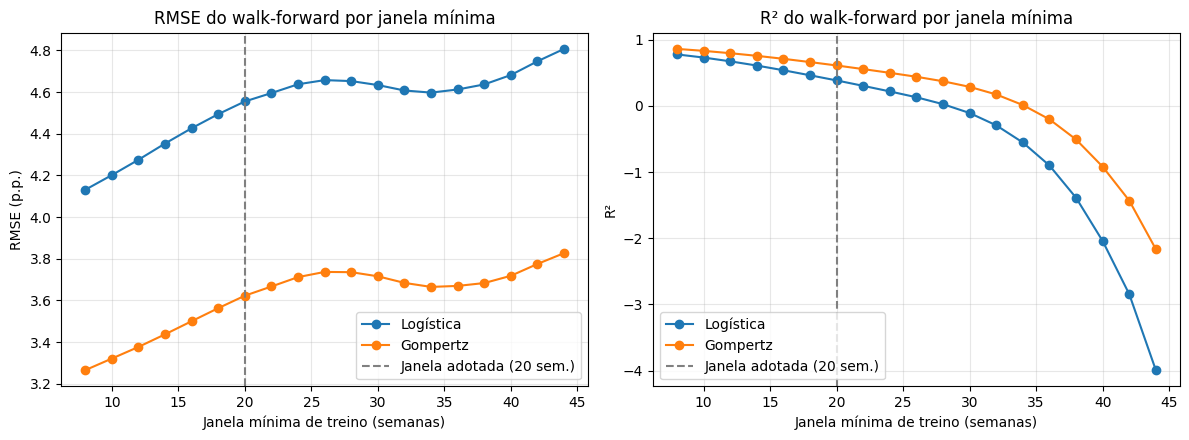

In [7]:
JANELAS_TESTADAS = range(8, 45, 2)

print(f"\nAnálise de sensibilidade da janela mínima de treino ({JANELAS_TESTADAS.start}–{JANELAS_TESTADAS.stop - 1} semanas):")
registros_sensibilidade = []
for janela in JANELAS_TESTADAS:
    for nome_modelo, modelo in [("Logística", modelo_logistico), ("Gompertz", modelo_gompertz)]:
        wf = validar_walk_forward(modelo, BOUNDS_PADRAO, t_arr, y_norm, janela, nome_modelo).dropna()
        if len(wf) < 5:
            continue
        registros_sensibilidade.append(
            {
                "min_train_semanas": janela,
                "modelo": nome_modelo,
                "n_folds": len(wf),
                "rmse_pp": np.sqrt(mean_squared_error(wf["y_real"], wf["y_previsto"])) * 100,
                "mae_pp": mean_absolute_error(wf["y_real"], wf["y_previsto"]) * 100,
                "r2": r2_score(wf["y_real"], wf["y_previsto"]),
            }
        )

sensibilidade = pd.DataFrame(registros_sensibilidade)
resumo_sensibilidade = (
    sensibilidade.groupby("modelo")
    .agg(
        rmse_min=("rmse_pp", "min"), rmse_max=("rmse_pp", "max"),
        mae_min=("mae_pp", "min"), mae_max=("mae_pp", "max"),
        r2_min=("r2", "min"), r2_max=("r2", "max"),
        janelas_testadas=("min_train_semanas", "count"),
    )
    .reset_index()
)
print(resumo_sensibilidade.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
for nome_modelo in ["Logística", "Gompertz"]:
    sub = sensibilidade[sensibilidade["modelo"] == nome_modelo].sort_values("min_train_semanas")
    ax1.plot(sub["min_train_semanas"], sub["rmse_pp"], marker="o", label=nome_modelo)
    ax2.plot(sub["min_train_semanas"], sub["r2"], marker="o", label=nome_modelo)

ax1.axvline(JANELA_MINIMA_WALK_FORWARD, color="grey", linestyle="--", label=f"Janela adotada ({JANELA_MINIMA_WALK_FORWARD} sem.)")
ax1.set_xlabel("Janela mínima de treino (semanas)")
ax1.set_ylabel("RMSE (p.p.)")
ax1.set_title("RMSE do walk-forward por janela mínima")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.axvline(JANELA_MINIMA_WALK_FORWARD, color="grey", linestyle="--", label=f"Janela adotada ({JANELA_MINIMA_WALK_FORWARD} sem.)")
ax2.set_xlabel("Janela mínima de treino (semanas)")
ax2.set_ylabel("R²")
ax2.set_title("R² do walk-forward por janela mínima")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("sensibilidade_min_train.png", dpi=150)
plt.show()

## 7. Identificabilidade do parâmetro de assíntota (L)

Com uma série ainda distante da maturidade, o teto físico `L` pode não estar bem
determinado pelos dados. O perfil de verossimilhança varre valores fixos de `L`,
reajusta `k` e `t0` para cada um, e usa o AIC para avaliar qual `L` melhor explica
o histórico — e o erro-padrão de um ajuste com `L` livre serve de diagnóstico
complementar.


Perfil de verossimilhança do parâmetro L (teto de avanço físico):
  [Logística] L com menor AIC no perfil: 0.372 (intervalo testado: 0.37–1.50)


  [Gompertz] L com menor AIC no perfil: 0.372 (intervalo testado: 0.37–1.50)


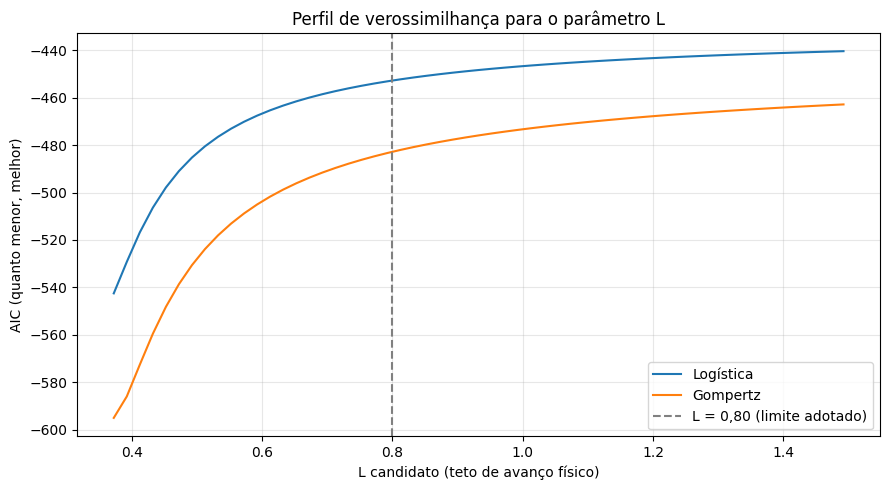


Ajuste com L livre (Logística): L = 0.3725 ± 0.0090 (erro-padrão).
Um erro-padrão elevado em relação ao próprio L indica que o teto físico ainda
está mal identificado pela série atual — maturidade insuficiente da curva.


In [8]:
def perfil_verossimilhanca(t_arr, y_norm, funcao_modelo, nome_modelo, l_max=1.5, passo=0.02):
    """Varre valores fixos de L e reajusta k, t0 para cada um, usando o AIC para
    avaliar quão bem identificado o teto físico está a partir dos dados atuais."""
    l_min = y_norm.max() * 1.01
    registros = []
    for L in np.arange(l_min, l_max, passo):
        def modelo_l_fixo(t, k, t0, L=L):
            return funcao_modelo(t, L, k, t0)

        try:
            popt, _ = curve_fit(
                modelo_l_fixo, t_arr, y_norm,
                p0=[0.05, t_arr.mean()],
                bounds=([0.0001, 1], [1.0, t_arr.max() * 3]),
                maxfev=10000,
            )
            y_pred = modelo_l_fixo(t_arr, *popt)
            rss = np.sum((y_norm - y_pred) ** 2)
            aic = len(t_arr) * np.log(rss / len(t_arr)) + 2 * 3
            registros.append({"L": L, "k": popt[0], "t0": popt[1], "RSS": rss, "AIC": aic})
        except RuntimeError:
            continue

    perfil = pd.DataFrame(registros)
    l_otimo = perfil.loc[perfil["AIC"].idxmin(), "L"]
    print(f"  [{nome_modelo}] L com menor AIC no perfil: {l_otimo:.3f} (intervalo testado: {l_min:.2f}–{l_max:.2f})")
    return perfil, l_otimo


print("\nPerfil de verossimilhança do parâmetro L (teto de avanço físico):")
perfil_log, l_otimo_log = perfil_verossimilhanca(t_arr, y_norm, modelo_logistico, "Logística")
perfil_gomp, l_otimo_gomp = perfil_verossimilhanca(t_arr, y_norm, modelo_gompertz, "Gompertz")

plt.figure(figsize=(9, 5))
plt.plot(perfil_log["L"], perfil_log["AIC"], label="Logística")
plt.plot(perfil_gomp["L"], perfil_gomp["AIC"], label="Gompertz")
plt.axvline(0.80, color="grey", linestyle="--", label="L = 0,80 (limite adotado)")
plt.xlabel("L candidato (teto de avanço físico)")
plt.ylabel("AIC (quanto menor, melhor)")
plt.title("Perfil de verossimilhança para o parâmetro L")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("perfil_L.png", dpi=150)
plt.show()

bounds_L_livre = ([y_norm.max() * 1.01, 0.001, 1], [1.5, 1.0, t_arr.max() * 3])
chute_L_livre = [max(0.85, y_norm.max() * 1.05), 0.05, t_arr.mean()]
popt_log_livre, pcov_log_livre = curve_fit(
    modelo_logistico, t_arr, y_norm, p0=chute_L_livre, bounds=bounds_L_livre, maxfev=20000
)
erro_padrao_L_livre = np.sqrt(np.diag(pcov_log_livre))[0]
print(f"\nAjuste com L livre (Logística): L = {popt_log_livre[0]:.4f} ± {erro_padrao_L_livre:.4f} (erro-padrão).")
print("Um erro-padrão elevado em relação ao próprio L indica que o teto físico ainda")
print("está mal identificado pela série atual — maturidade insuficiente da curva.")

## 8. Cenários de teto físico — L = 0,80 vs. L = 1,00

Compara o efeito de duas premissas de teto físico: L = 0,80 (adotada como referência)
e L = 1,00 (execução integral do escopo), reajustando `k` e `t0` para cada uma.

In [9]:
def ajustar_cenario_L_fixo(nome_modelo, funcao_modelo, L, chute_t0):
    def modelo_l_fixo(t, k, t0):
        return funcao_modelo(t, L, k, t0)

    popt, _ = curve_fit(
        modelo_l_fixo, t_arr, y_norm, p0=[0.05, chute_t0],
        bounds=([0.0001, 1], [1.0, t_arr.max() * 3]), maxfev=20000,
    )
    k, t0 = popt
    y_pred = modelo_l_fixo(t_arr, *popt)

    r2 = r2_score(y_norm, y_pred)
    rmse = np.sqrt(mean_squared_error(y_norm, y_pred)) * 100
    mae = mean_absolute_error(y_norm, y_pred) * 100
    rss = np.sum((y_norm - y_pred) ** 2)
    aic = len(t_arr) * np.log(rss / len(t_arr)) + 2 * 2

    t_fim = brentq(lambda t: modelo_l_fixo(t, k, t0) - (L * LIMIAR_CONCLUSAO), 1, 2000)

    return {
        "modelo": nome_modelo, "L": L, "k": k, "t0": t0,
        "R2": r2, "RMSE_pp": rmse, "MAE_pp": mae, "AIC": aic,
        "semana_conclusao_99pct": round(t_fim, 1),
        "data_conclusao_99pct": semana_para_data(t_fim).date(),
    }


print("\nComparação de cenários — L = 0,80 (premissa adotada) vs. L = 1,00 (execução integral):")
cenarios_L = pd.DataFrame(
    [
        ajustar_cenario_L_fixo("Logística", modelo_logistico, 0.80, chute_t0=67),
        ajustar_cenario_L_fixo("Logística", modelo_logistico, 1.00, chute_t0=70),
        ajustar_cenario_L_fixo("Gompertz", modelo_gompertz, 0.80, chute_t0=50),
        ajustar_cenario_L_fixo("Gompertz", modelo_gompertz, 1.00, chute_t0=63),
    ]
)
print(cenarios_L.to_string(index=False))

linhas_resumo_L = []
for nome_modelo in ["Logística", "Gompertz"]:
    sub = cenarios_L[cenarios_L["modelo"] == nome_modelo].sort_values("L")
    l80 = sub[sub["L"] == 0.80].iloc[0]
    l100 = sub[sub["L"] == 1.00].iloc[0]
    atraso_dias = (pd.Timestamp(l100["data_conclusao_99pct"]) - pd.Timestamp(l80["data_conclusao_99pct"])).days
    linhas_resumo_L.append(
        {
            "modelo": nome_modelo,
            "conclusao_L080": l80["data_conclusao_99pct"],
            "conclusao_L100": l100["data_conclusao_99pct"],
            "atraso_dias_ao_forcar_100pct": atraso_dias,
            "R2_L080": l80["R2"],
            "R2_L100": l100["R2"],
        }
    )
    print(f"  [{nome_modelo}] forçar 100% adia a conclusão em {atraso_dias} dias "
          f"({l80['data_conclusao_99pct']} -> {l100['data_conclusao_99pct']}), "
          f"R² cai de {l80['R2']:.4f} para {l100['R2']:.4f}.")

resumo_cenarios_L = pd.DataFrame(linhas_resumo_L)


Comparação de cenários — L = 0,80 (premissa adotada) vs. L = 1,00 (execução integral):
   modelo   L        k        t0       R2  RMSE_pp   MAE_pp         AIC  semana_conclusao_99pct data_conclusao_99pct
Logística 0.8 0.033080 67.334015 0.892546 3.599088 3.099616 -454.779582                   206.2           2028-10-09
Logística 1.0 0.030056 80.557455 0.882662 3.760989 3.235390 -448.707380                   233.4           2029-04-18
 Gompertz 0.8 0.019415 49.730291 0.930489 2.894729 2.534133 -484.834451                   286.7           2030-04-25
 Gompertz 1.0 0.016239 62.635242 0.920224 3.101109 2.714376 -475.330642                   345.9           2031-06-14
  [Logística] forçar 100% adia a conclusão em 191 dias (2028-10-09 -> 2029-04-18), R² cai de 0.8925 para 0.8827.
  [Gompertz] forçar 100% adia a conclusão em 415 dias (2030-04-25 -> 2031-06-14), R² cai de 0.9305 para 0.9202.


## 9. Consolidação e exportação

Todos os resultados intermediários são reunidos em um único arquivo Excel, com uma
aba por análise.

In [10]:
colunas_evm = [c for i in range(9) for c in (f"sv_v{i}", f"spi_v{i}")]
colunas_export = (
    ["semana", "data_corte"] + [f"planejado_v{i}" for i in range(9)]
    + ["executado_real"] + colunas_evm + ["predicao_logistica", "predicao_gompertz"]
)

planilhas = {
    "dados_preditivos": df_final[colunas_export],
    "parametros_modelos": parametros_modelos,
    "resumo_ajuste_in_sample": resumo_ajuste,
    "previsoes_conclusao": previsoes_conclusao,
    "walk_forward_detalhe": wf_completo,
    "walk_forward_resumo": resumo_walk_forward,
    "sensibilidade_min_train": sensibilidade,
    "sensibilidade_resumo": resumo_sensibilidade,
    "comparativo_L_080_100": cenarios_L,
    "comparativo_L_resumo": resumo_cenarios_L,
}

print(f"\nExportando resultados consolidados para '{ARQUIVO_SAIDA}'...")
with pd.ExcelWriter(ARQUIVO_SAIDA, engine="openpyxl") as writer:
    for aba, dados in planilhas.items():
        dados_export = dados.copy()
        for coluna in dados_export.columns:
            if dados_export[coluna].dtype == object:
                dados_export[coluna] = dados_export[coluna].astype(str)
        dados_export.to_excel(writer, sheet_name=aba, index=False)
print(f"{len(planilhas)} abas gravadas.")


Exportando resultados consolidados para 'AVANCO_SEMANAL_PREDITIVO.xlsx'...
10 abas gravadas.


## 10. Figuras finais

Três painéis de síntese: avanço real x projeções x linhas de base, evolução de SV/SPI
por linha de base, e um dashboard integrado combinando os dois anteriores.

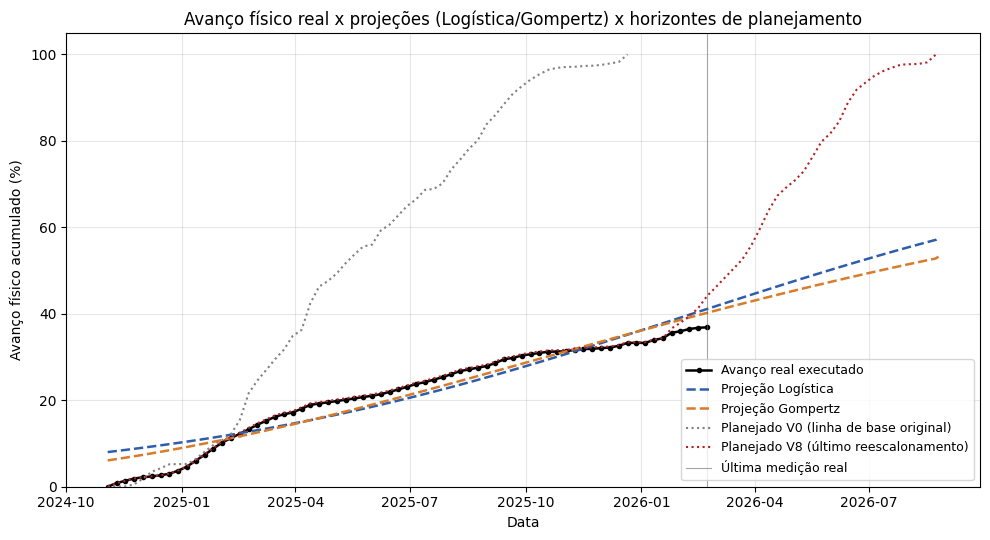

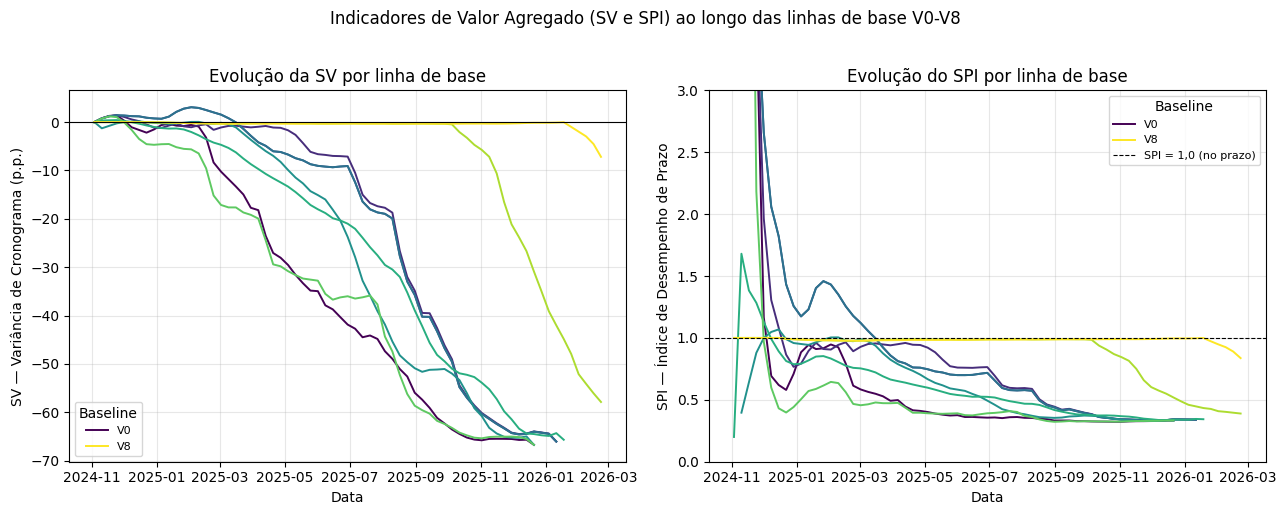

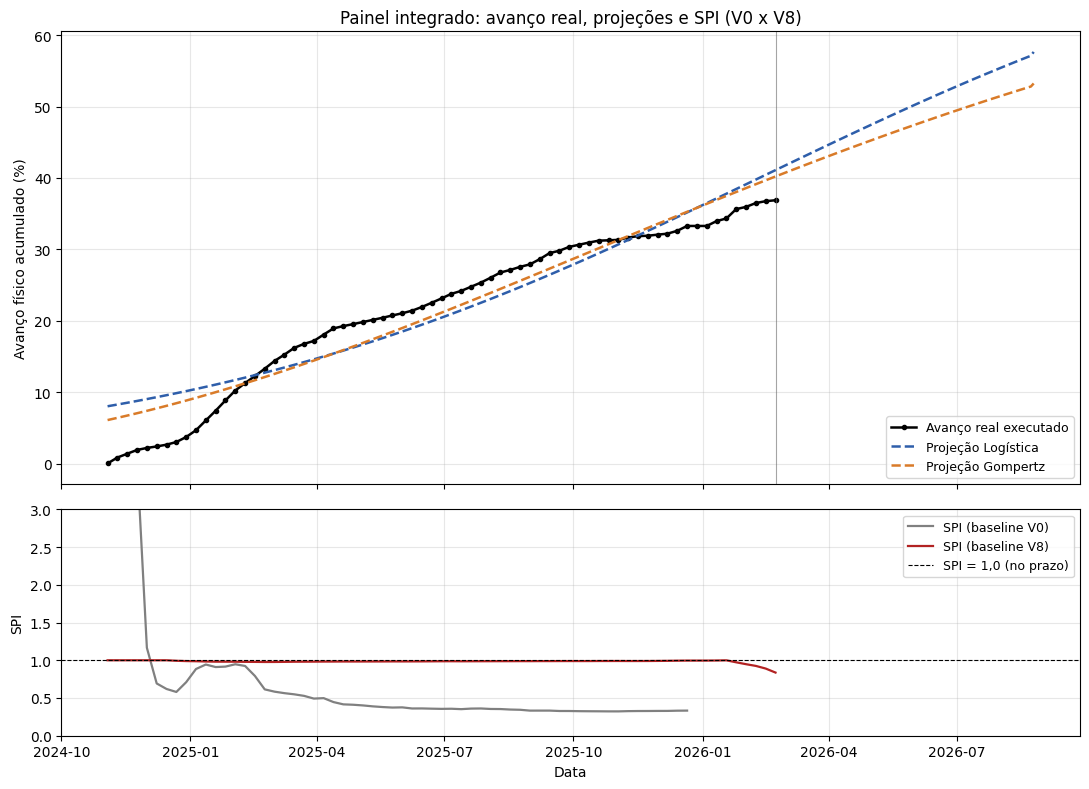


Figuras geradas: figura4_curva_s_projecoes.png, figura9_sv_spi_evolucao.png, figura10_matriz_integrada_dashboard.png, perfil_L.png, sensibilidade_min_train.png


In [11]:
ultima_semana_real = df_final.loc[df_final["executado_real"].notna(), "semana"].max()
data_hoje = df_final.loc[df_final["semana"] == ultima_semana_real, "data_corte"].values[0]
real = df_final[df_final["executado_real"].notna()]

# Figura 4 — avanço real x modelos x horizontes de planejamento
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(real["data_corte"], real["executado_real"] * 100, "o-", color="black",
        markersize=3, linewidth=1.8, label="Avanço real executado")
ax.plot(df_final["data_corte"], df_final["predicao_logistica"] * 100, "--",
        color="#2E5EAA", linewidth=1.8, label="Projeção Logística")
ax.plot(df_final["data_corte"], df_final["predicao_gompertz"] * 100, "--",
        color="#D97B29", linewidth=1.8, label="Projeção Gompertz")

v0 = df_final[df_final["planejado_v0"].notna()]
v8 = df_final[df_final["planejado_v8"].notna()]
ax.plot(v0["data_corte"], v0["planejado_v0"] * 100, ":", color="gray",
        linewidth=1.5, label="Planejado V0 (linha de base original)")
ax.plot(v8["data_corte"], v8["planejado_v8"] * 100, ":", color="firebrick",
        linewidth=1.5, label="Planejado V8 (último reescalonamento)")
ax.axvline(data_hoje, color="dimgray", linewidth=0.8, alpha=0.6, label="Última medição real")

ax.set_xlabel("Data")
ax.set_ylabel("Avanço físico acumulado (%)")
ax.set_title("Avanço físico real x projeções (Logística/Gompertz) x horizontes de planejamento")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig("figura4_curva_s_projecoes.png", dpi=150)
plt.show()

# Figura 9 — evolução de SV e SPI por linha de base
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
cores = cm.viridis(np.linspace(0, 1, 9))
for i in range(9):
    sub_sv = df_final[df_final[f"sv_v{i}"].notna()]
    ax1.plot(sub_sv["data_corte"], sub_sv[f"sv_v{i}"] * 100, color=cores[i], linewidth=1.4,
              label=f"V{i}" if i in (0, 8) else None)
    sub_spi = df_final[df_final[f"spi_v{i}"].notna()]
    ax2.plot(sub_spi["data_corte"], sub_spi[f"spi_v{i}"], color=cores[i], linewidth=1.4,
              label=f"V{i}" if i in (0, 8) else None)

ax1.axhline(0, color="black", linewidth=0.8)
ax1.set_xlabel("Data")
ax1.set_ylabel("SV — Variância de Cronograma (p.p.)")
ax1.set_title("Evolução da SV por linha de base")
ax1.legend(title="Baseline", fontsize=8)
ax1.grid(alpha=0.3)

ax2.axhline(1.0, color="black", linewidth=0.8, linestyle="--", label="SPI = 1,0 (no prazo)")
ax2.set_xlabel("Data")
ax2.set_ylabel("SPI — Índice de Desempenho de Prazo")
ax2.set_title("Evolução do SPI por linha de base")
ax2.set_ylim(0, 3)  # nas primeiras semanas o planejado é próximo de zero e distorce o SPI
ax2.legend(title="Baseline", fontsize=8)
ax2.grid(alpha=0.3)

plt.suptitle("Indicadores de Valor Agregado (SV e SPI) ao longo das linhas de base V0-V8", y=1.02)
plt.tight_layout()
plt.savefig("figura9_sv_spi_evolucao.png", dpi=150, bbox_inches="tight")
plt.show()

# Figura 10 — dashboard integrado
fig, (axA, axB) = plt.subplots(2, 1, figsize=(11, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

axA.plot(real["data_corte"], real["executado_real"] * 100, "o-", color="black",
         markersize=3, linewidth=1.8, label="Avanço real executado")
axA.plot(df_final["data_corte"], df_final["predicao_logistica"] * 100, "--",
         color="#2E5EAA", linewidth=1.8, label="Projeção Logística")
axA.plot(df_final["data_corte"], df_final["predicao_gompertz"] * 100, "--",
         color="#D97B29", linewidth=1.8, label="Projeção Gompertz")
axA.axvline(data_hoje, color="dimgray", linewidth=0.8, alpha=0.6)
axA.set_ylabel("Avanço físico acumulado (%)")
axA.set_title("Painel integrado: avanço real, projeções e SPI (V0 x V8)")
axA.legend(loc="lower right", fontsize=9)
axA.grid(alpha=0.3)

sub_v0 = df_final[df_final["spi_v0"].notna()]
sub_v8 = df_final[df_final["spi_v8"].notna()]
axB.plot(sub_v0["data_corte"], sub_v0["spi_v0"], color="gray", linewidth=1.6, label="SPI (baseline V0)")
axB.plot(sub_v8["data_corte"], sub_v8["spi_v8"], color="firebrick", linewidth=1.6, label="SPI (baseline V8)")
axB.axhline(1.0, color="black", linestyle="--", linewidth=0.8, label="SPI = 1,0 (no prazo)")
axB.set_xlabel("Data")
axB.set_ylabel("SPI")
axB.set_ylim(0, 3)
axB.legend(fontsize=9)
axB.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figura10_matriz_integrada_dashboard.png", dpi=150)
plt.show()

print("\nFiguras geradas: figura4_curva_s_projecoes.png, figura9_sv_spi_evolucao.png, "
      "figura10_matriz_integrada_dashboard.png, perfil_L.png, sensibilidade_min_train.png")